# MVP de Machine Learning: Previsão de Adesão a Depósito a Prazo

## Definição do problema

Este MVP tem como objetivo desenvolver um modelo de Machine Learning capaz de prever se um cliente de uma instituição bancária irá aderir ou não a um depósito a prazo após uma campanha de marketing.

O problema é relevante porque campanhas de contato com clientes geram custo operacional e dependem de boa segmentação. Um modelo preditivo pode ajudar a priorizar clientes com maior probabilidade de adesão, aumentando a eficiência comercial.

A tarefa será tratada como um problema de classificação supervisionada, em que a variável-alvo é `y`, indicando se o cliente aderiu (`yes`) ou não (`no`) ao produto oferecido.

Esse problema pode ser resolvido com Machine Learning porque há dados históricos rotulados e atributos que podem influenciar a decisão do cliente, como idade, profissão, saldo, tipo de contato, número de contatos realizados e histórico de campanhas anteriores.

## Premissas e restrições

- O notebook deve ser reproduzível do início ao fim no Google Colab.
- O dataset será obtido a partir de fonte pública.
- O foco deste MVP é construir uma solução coerente, reproduzível e bem documentada.
- O objetivo não é obter o modelo mais complexo possível, mas uma solução tecnicamente justificada.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Vdamattos0/MVP-de-Machine-Learning/refs/heads/main/bank-full.csv"
df = pd.read_csv(url, sep=";")

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Apresentação dos dados

O dataset utilizado neste MVP é o **Bank Marketing**, disponível na UCI Machine Learning Repository.

Segundo a UCI, os dados estão relacionados a campanhas de marketing direto de uma instituição bancária portuguesa, com o objetivo de prever se o cliente irá aderir ou não a um depósito a prazo.

A variável-alvo do problema é `y`, que indica se o cliente assinou (`yes`) ou não (`no`) o produto oferecido.


In [ ]:
print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())

Dimensões do dataset: (45211, 17)

Primeiras linhas:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
print("\nTipos das variáveis:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isna().sum().sort_values(ascending=False))


Tipos das variáveis:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Valores ausentes por coluna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


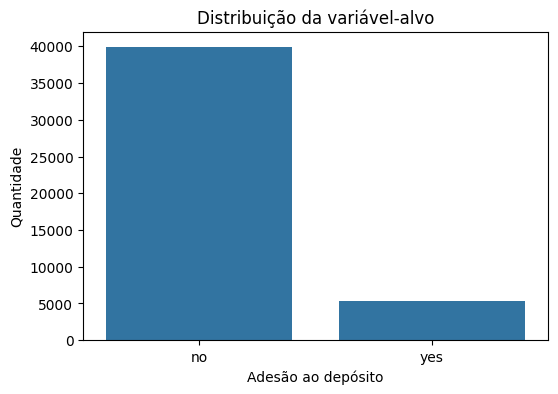

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="y")
plt.title("Distribuição da variável-alvo")
plt.xlabel("Adesão ao depósito")
plt.ylabel("Quantidade")
plt.show()

## Análise exploratória inicial

A distribuição da variável-alvo mostra que o conjunto de dados é desbalanceado, com predominância de clientes que **não aderiram** ao depósito a prazo. Essa característica deve ser considerada na avaliação dos modelos, pois métricas como acurácia isoladamente podem ser insuficientes para refletir o desempenho real.

Na sequência, será feita a preparação dos dados para modelagem, incluindo separação entre variáveis explicativas e alvo, transformação da variável-alvo e criação de pipelines para tratamento de atributos numéricos e categóricos.

In [ ]:
df["y"] = df["y"].map({"no": 0, "yes": 1})
df["y"].value_counts()

,count
y,
0,39922
1,5289


In [ ]:
X = df.drop(columns=["y"])
y = df["y"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Colunas categóricas:", cat_cols)
print("\nColunas numéricas:", num_cols)

Colunas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Colunas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## Preparação dos dados

Para garantir reprodutibilidade e evitar vazamento de dados, o pré-processamento será incorporado a pipelines.

As variáveis numéricas serão tratadas com imputação pela mediana e padronização. As variáveis categóricas serão tratadas com imputação pela categoria mais frequente e codificação One-Hot Encoding.

Essa estratégia permite que todas as transformações sejam aprendidas apenas a partir dos dados de treino e reaplicadas corretamente aos dados de teste.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 16)
X_test: (9043, 16)
y_train: (36168,)
y_test: (9043,)


## Modelagem inicial

Nesta etapa, serão comparadas três abordagens:

- um baseline simples, com `DummyClassifier`
- um modelo linear, com `LogisticRegression`
- um modelo baseado em árvores, com `RandomForestClassifier`

O baseline é importante para verificar se os modelos mais elaborados realmente trazem ganho em relação a uma solução ingênua.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    print(f"Modelo: {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred))

    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": auc
    }

In [ ]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=SEED))
])

In [ ]:
results = []

results.append(evaluate_model("DummyClassifier", baseline_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("LogisticRegression", log_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("RandomForest", rf_model, X_train, X_test, y_train, y_test))

Modelo: DummyClassifier
Accuracy:  0.8830
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC AUC:   0.5000

Matriz de confusão:
[[7985    0]
 [1058    0]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7985
           1       0.00      0.00      0.00      1058

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Modelo: LogisticRegression
Accuracy:  0.9012
Precision: 0.6445
Recall:    0.3478
F1-score:  0.4518
ROC AUC:   0.9056

Matriz de confusão:
[[7782  203]
 [ 690  368]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

Modelo: RandomForest
Accuracy:  0.9045
Precision: 0.6506
Recall:    0.3960
F1-score:  0.4924
ROC AUC:   0.9263

Matriz de confusão:
[[7760  225]
 [ 639  419]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.40      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       

In [ ]:
results_df = pd.DataFrame(results)
results_df

,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC
0,DummyClassifier,0.883003,0.000000,0.000000,0.000000,0.500000
1,LogisticRegression,0.901250,0.644483,0.347826,0.451811,0.905574
2,RandomForest,0.904456,0.650621,0.396030,0.492362,0.926286


## Otimização de hiperparâmetros

Após a comparação inicial entre os modelos, o Random Forest apresentou o melhor desempenho geral, especialmente nas métricas F1-score e ROC AUC, que são relevantes neste problema devido ao desbalanceamento da variável-alvo.

Por esse motivo, foi escolhido para a etapa de ajuste de hiperparâmetros. A estratégia adotada foi o `GridSearchCV`, buscando combinações de parâmetros importantes para o comportamento do modelo, como número de árvores, profundidade máxima e tamanho mínimo de divisão dos nós.

A métrica escolhida para otimização foi o **F1-score**, pois ela equilibra precisão e recall, sendo mais adequada do que a acurácia isolada em cenários desbalanceados.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'balance',
                                                                          'day',
                                                                          'duration',
                                                                          'campaign',
                                                                          'pdays',
                                                                          'previous']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEnc...re'))]),
                                                                         ['job',
                                                                          'marital',
                                                                          'education',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'month',
                                                                          'poutcome'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [ ]:
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

print("\nMelhor F1-score médio na validação cruzada:")
print(grid_search.best_score_)

Melhores parâmetros encontrados:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Melhor F1-score médio na validação cruzada:
0.49516533947127916


In [ ]:
best_model = grid_search.best_estimator_
best_results = evaluate_model(
    "RandomForest Tunado",
    best_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Modelo: RandomForest Tunado
Accuracy:  0.9083
Precision: 0.6832
Recall:    0.4036
F1-score:  0.5074
ROC AUC:   0.9303

Matriz de confusão:
[[7787  198]
 [ 631  427]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7985
           1       0.68      0.40      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.90      0.91      0.90      9043



In [ ]:
results.append(best_results)
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-score", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC
3,RandomForest Tunado,0.908327,0.683200,0.403592,0.507427,0.930281
2,RandomForest,0.904456,0.650621,0.396030,0.492362,0.926286
1,LogisticRegression,0.901250,0.644483,0.347826,0.451811,0.905574
0,DummyClassifier,0.883003,0.000000,0.000000,0.000000,0.500000


## Avaliação dos resultados

As métricas utilizadas neste trabalho foram acurácia, precisão, recall, F1-score e ROC AUC.

A acurácia fornece uma visão geral da proporção de acertos do modelo, mas, como a base apresenta desbalanceamento entre as classes, ela não deve ser analisada isoladamente.

A precisão é importante para medir, entre os clientes classificados como aderentes, quantos realmente aderiram. O recall mede a capacidade do modelo de identificar corretamente os clientes que de fato aderiram ao produto. O F1-score foi considerado especialmente relevante neste cenário, pois equilibra precisão e recall. O ROC AUC também foi utilizado para avaliar a capacidade de separação entre as classes.

## Discussão dos resultados

O baseline com `DummyClassifier` apresentou desempenho fraco para a classe positiva, o que era esperado, já que esse tipo de abordagem tende a favorecer a classe majoritária.

A `LogisticRegression` apresentou melhora em relação ao baseline, mostrando que mesmo um modelo linear simples já é capaz de capturar padrões relevantes no conjunto de dados.

O `RandomForestClassifier` apresentou desempenho superior, especialmente em métricas mais apropriadas para o problema, como F1-score e ROC AUC. Após o ajuste de hiperparâmetros com `GridSearchCV`, observou-se uma melhora adicional, ainda que moderada, em relação à versão inicial do modelo.

Os resultados mostram que o modelo ajustado conseguiu melhor equilíbrio entre precisão e recall. Ainda assim, o recall da classe positiva permanece limitado, indicando que parte dos clientes realmente aderentes ainda não é corretamente identificada. Isso sugere oportunidades futuras de melhoria com técnicas de balanceamento, novas transformações de atributos e testes com outros algoritmos.

## Conclusão

Este MVP teve como objetivo prever se um cliente aderiria ou não a um depósito a prazo em uma campanha de marketing bancário.

Foi utilizado o dataset **Bank Marketing**, disponível na **UCI Machine Learning Repository**, contendo dados demográficos, financeiros e históricos de contato com clientes. O problema foi tratado como uma tarefa de classificação supervisionada, tendo como variável-alvo `y`.

Ao longo do trabalho, foram realizadas etapas de apresentação do problema, análise exploratória inicial, transformação da variável-alvo, preparação dos dados com pipelines reproduzíveis e divisão estratificada entre treino e teste.

Foram comparados quatro resultados principais: um baseline com `DummyClassifier`, os modelos `LogisticRegression` e `RandomForestClassifier`, além de uma versão ajustada do Random Forest com busca de hiperparâmetros via `GridSearchCV`.

O melhor resultado foi obtido com o **RandomForest Tunado**, que apresentou o maior F1-score e o maior ROC AUC entre os modelos avaliados. Por esse motivo, ele foi escolhido como a melhor solução deste MVP.

Como limitações, destacam-se o desbalanceamento da base e o recall ainda moderado para a classe positiva. Como próximos passos, seria interessante testar técnicas de balanceamento, expandir a engenharia de atributos e avaliar outros algoritmos com potencial de ganho adicional.

Fonte do dataset: UCI Machine Learning Repository. Dataset: Bank Marketing. Disponível em: https://archive.ics.uci.edu/dataset/222/bank+marketing

## Limitações do dataset

Apesar de ser adequado para este MVP, o dataset apresenta algumas limitações. A base é desbalanceada, com predominância da classe negativa, o que dificulta a identificação dos clientes que realmente aderem ao produto. Além disso, os dados representam um contexto específico de campanhas de marketing bancário, o que pode limitar a generalização dos resultados para outras instituições ou períodos.